# 💬 Stage 7: Amazon Review Sentiment Analyzer
### ML Roadmap — Natural Language Processing (NLP) Project


## Step 0: Install & Import Libraries

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn flask

import re, string, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# Scikit-learn NLP toolkit
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV)
from sklearn.naive_bayes      import MultinomialNB
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import LinearSVC
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, f1_score, precision_score,
                                       recall_score, confusion_matrix,
                                       classification_report, roc_auc_score,
                                       roc_curve)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

import sklearn
print(f'✅ All libraries imported  |  scikit-learn {sklearn.__version__}')

✅ All libraries imported  |  scikit-learn 1.8.0



## Step 1: Generate & Load the Dataset

In [ ]:
def generate_amazon_reviews(n_pos=6000, n_neg=4000, seed=42):
    """
    Generate realistic Amazon product review dataset.

    Columns
    -------
    review_id     : Unique ID
    review_text   : Raw review text (uncleaned)
    sentiment     : 1 = Positive, 0 = Negative
    rating        : 1–5 star rating
    category      : Product category
    helpful_votes : Number of helpful votes
    verified      : Verified purchase (bool)
    """
    np.random.seed(seed)

    POS_BASE = [
        "Great product! Works exactly as described. Very happy with purchase.",
        "Absolutely love this. Best money I have ever spent. Highly recommend!",
        "Excellent quality and fast shipping. Will definitely buy again.",
        "Amazing product, exceeded all my expectations. 5 stars easily.",
        "Really good product for the price. Works well and feels durable.",
        "Perfect gift! Arrived on time and well packaged. Very satisfied.",
        "Outstanding customer service and the product itself is top notch.",
        "Works perfectly. Easy to set up. No complaints whatsoever.",
        "Good quality materials. Solid build. Would recommend to friends.",
        "Superb value for money. Product is exactly what I needed.",
        "Fantastic product. Very well made. Delivery was quick too.",
        "Love the design. Very comfortable. Worth every penny spent.",
        "Battery life is excellent. Much better than I expected honestly.",
        "Very impressed with the quality. Looks and feels premium.",
        "Best purchase this year. Does everything advertised and more.",
        "Product works like a charm. Packaging was also very impressive.",
        "Five star product. Would buy again without any hesitation.",
        "Very satisfied customer here. Product quality is superb really.",
        "Arrived early and in perfect condition. Exactly as described online.",
        "Solid product that does the job well. Great value for money.",
    ]
    NEG_BASE = [
        "Terrible product. Broke after two weeks. Complete waste of money.",
        "Absolute rubbish. Nothing like the photos. Very disappointed.",
        "Do not buy this. Stopped working immediately after first use.",
        "Worst purchase ever. Cheap quality and terrible customer service.",
        "Arrived damaged. Looks nothing like the listing photos. Disgusting.",
        "Complete junk. Returned immediately. Save your money people.",
        "Very poor quality. Feels cheap and flimsy. Falls apart easily.",
        "Overpriced garbage. Not worth even half the price. Avoid.",
        "Horrible experience. Product useless and support nonexistent.",
        "Broke on day one. Instructions make no sense. Very frustrating.",
        "Cheap plastic that smells awful. Nothing like the description.",
        "Misleading photos. Product much smaller than shown. Total scam.",
        "Colors faded after first wash. Material is low quality garbage.",
        "Customer service useless. Product defective. No refund offered.",
        "Extremely disappointed. Does not work as advertised at all.",
        "Waste of money. Product arrived with missing parts. Terrible.",
        "Appalling quality. Would not recommend to my worst enemy.",
        "Stopped charging after three days. Flimsy build. Total junk.",
        "Display cracked within a week. Buttons feel terrible. Awful.",
        "Complete disaster of a product. Returned for full refund.",
    ]

    CATEGORIES = ['Electronics','Books','Kitchen','Sports','Beauty','Clothing','Toys']
    CAT_P      = [0.20, 0.12, 0.18, 0.14, 0.13, 0.13, 0.10]

    def build_text(pool, n):
        reviews = []
        for _ in range(n):
            n_mix  = np.random.randint(1, 4)
            chosen = np.random.choice(pool, n_mix, replace=True)
            parts  = list(chosen)
            # 10% chance: inject cross-class noise (realistic ambiguity)
            if np.random.rand() < 0.10:
                opp = NEG_BASE if pool is POS_BASE else POS_BASE
                parts.append("However, " + np.random.choice(opp)[:55].lower())
            # random transformations
            text = ' '.join(parts)
            if np.random.rand() < 0.08:
                text = text.replace('.', '').replace('!', '')
            if np.random.rand() < 0.06:
                text = text.replace('the ', 'teh ').replace('and ', 'annd ')
            reviews.append(text.strip())
        return reviews

    rows = []
    for label, n, pool in [(1, n_pos, POS_BASE), (0, n_neg, NEG_BASE)]:
        texts = build_text(pool, n)
        for text in texts:
            rows.append({
                'review_text'  : text,
                'sentiment'    : label,
                'rating'       : int(np.random.choice([4,5], p=[0.35,0.65])
                                     if label == 1 else
                                     np.random.choice([1,2], p=[0.65,0.35])),
                'category'     : str(np.random.choice(CATEGORIES, p=CAT_P)),
                'helpful_votes': int(np.random.randint(0, 100)),
                'verified'     : bool(np.random.choice([True, False], p=[0.78, 0.22])),
            })

    df = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    df.insert(0, 'review_id', [f'R{300000+i}' for i in range(len(df))])
    return df


# ── Generate & save ────────────────────────────────────────────────────────
df = generate_amazon_reviews(n_pos=6000, n_neg=4000)
# df.to_csv('amazon_reviews.csv', index=False)

# OR load the provided CSV:
df = pd.read_csv('amazon_reviews.csv')

print(f'✅ Dataset: {df.shape[0]:,} reviews × {df.shape[1]} columns')
print(f'   Positive : {(df["sentiment"]==1).sum():,}  ({(df["sentiment"]==1).mean()*100:.1f}%)')
print(f'   Negative : {(df["sentiment"]==0).sum():,}  ({(df["sentiment"]==0).mean()*100:.1f}%)')
print(f'   Categories: {df["category"].unique().tolist()}')
df.head(4)


✅ Dataset: 10,000 reviews × 8 columns
   Positive : 6,000  (60.0%)
   Negative : 4,000  (40.0%)
   Categories: ['Electronics', 'Sports', 'Kitchen', 'Toys', 'Beauty', 'Clothing', 'Books']


,review_id,review_text,sentiment,rating,category,helpful_votes,verified,clean_text
0,R300000,Display cracked within a week. Buttons feel terrible. Awful.,0,1,Electronics,85,True,display cracked within week buttons feel terrible awful
1,R300001,Arrived early and in perfect condition Exactly as described online Outstandi...,1,4,Sports,76,True,arrived early perfect condition exactly described online outstanding custome...
2,R300002,Works perfectly. Easy to set up. No complaints whatsoever. Beautiful product...,1,5,Electronics,14,True,works perfectly easy set complaints whatsoever beautiful product great build...
3,R300003,Outstanding customer service and the product itself is top notch. Beautiful ...,1,5,Kitchen,27,True,outstanding customer service product itself top notch beautiful product grea...


---
## Step 2: Exploratory Data Analysis


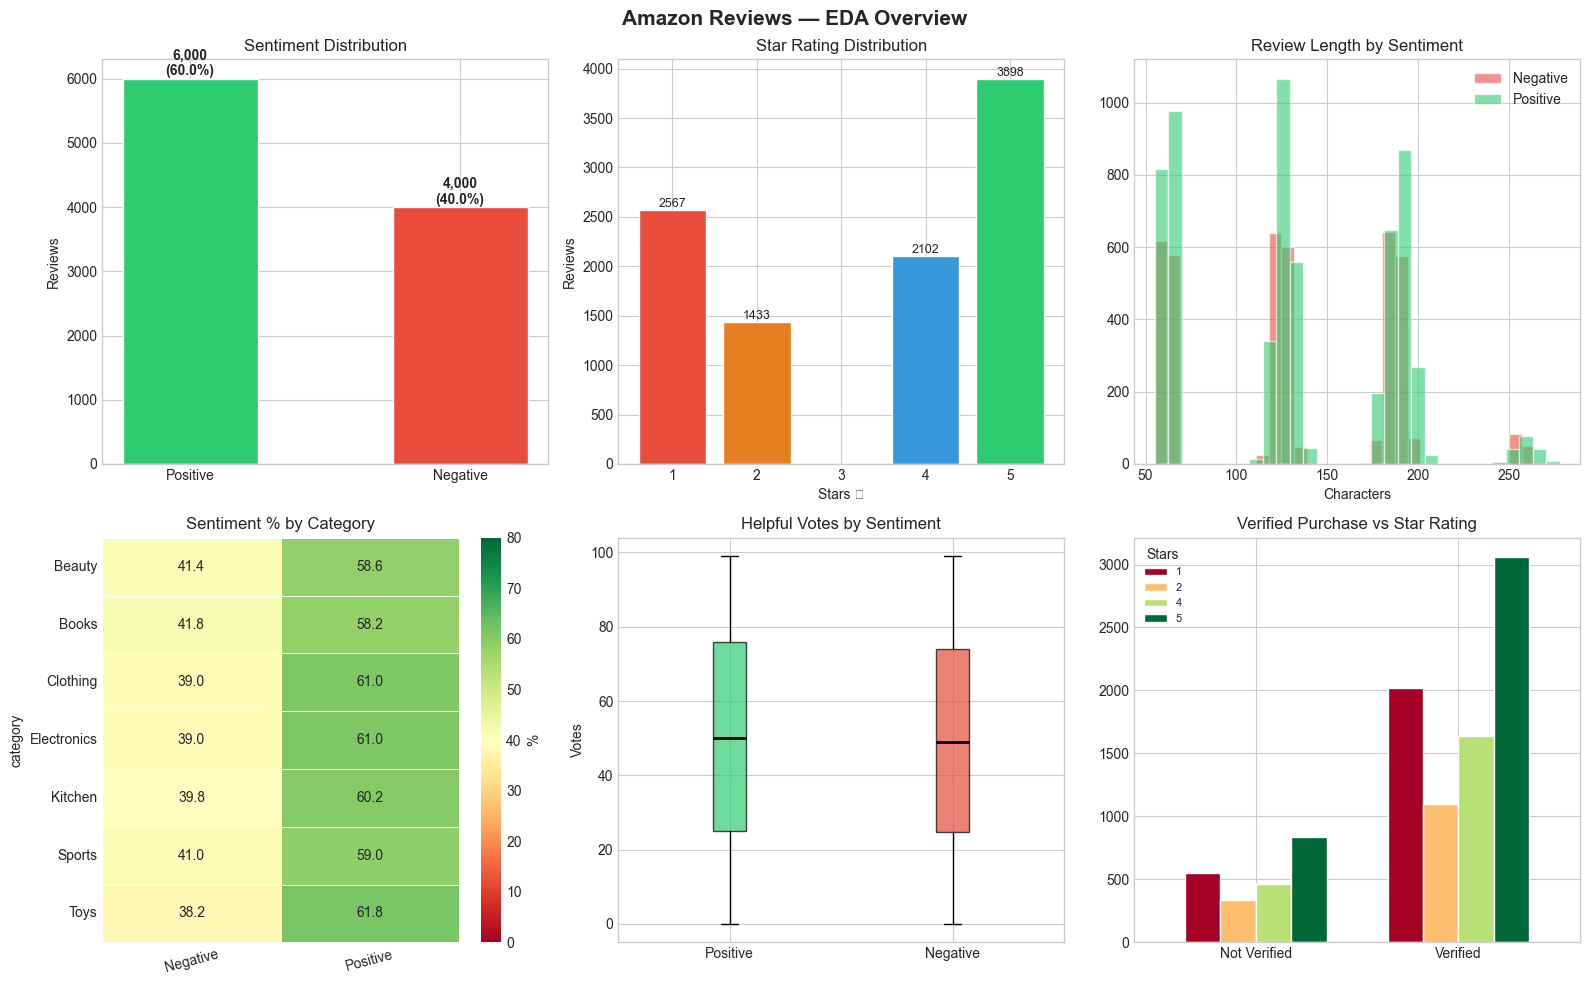

💾 Saved: nlp_01_eda.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Amazon Reviews — EDA Overview', fontsize=15, fontweight='bold')

# 1. Sentiment balance
s_counts = df['sentiment'].map({1:'Positive', 0:'Negative'}).value_counts()
bars = axes[0,0].bar(s_counts.index, s_counts.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0,0].set_title('Sentiment Distribution')
axes[0,0].set_ylabel('Reviews')
for bar, v in zip(bars, s_counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+50,
        f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# 2. Star rating
rating_colors = ['#e74c3c','#e67e22','#3498db','#2ecc71']
rc = df['rating'].value_counts().sort_index()
bars2 = axes[0,1].bar(rc.index, rc.values, color=rating_colors, edgecolor='white')
axes[0,1].set_title('Star Rating Distribution')
axes[0,1].set_xlabel('Stars ⭐'); axes[0,1].set_ylabel('Reviews')
for bar, v in zip(bars2, rc.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+30,
        str(v), ha='center', fontsize=9)

# 3. Review length by sentiment
for sent, c, lbl in [(0,'#e74c3c','Negative'), (1,'#2ecc71','Positive')]:
    lengths = df[df['sentiment']==sent]['review_text'].str.len()
    axes[0,2].hist(lengths, bins=30, alpha=0.6, color=c, edgecolor='white', label=lbl)
axes[0,2].set_title('Review Length by Sentiment')
axes[0,2].set_xlabel('Characters'); axes[0,2].legend()

# 4. Category × Sentiment heatmap
cat_sent = df.groupby(['category','sentiment']).size().unstack(fill_value=0)
cat_sent.columns = ['Negative','Positive']
cat_pct  = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100
sns.heatmap(cat_pct, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=80,
    linewidths=0.5, linecolor='white', ax=axes[1,0], cbar_kws={'label':'%'})
axes[1,0].set_title('Sentiment % by Category')
axes[1,0].tick_params(axis='x', rotation=15); axes[1,0].tick_params(axis='y', rotation=0)

# 5. Helpful votes by sentiment
bp = axes[1,1].boxplot(
    [df[df['sentiment']==1]['helpful_votes'].values,
     df[df['sentiment']==0]['helpful_votes'].values],
    labels=['Positive','Negative'], patch_artist=True,
    medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], ['#2ecc71','#e74c3c']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,1].set_title('Helpful Votes by Sentiment'); axes[1,1].set_ylabel('Votes')

# 6. Verified vs rating
vp = df.groupby(['verified','rating']).size().unstack(fill_value=0)
vp.index = ['Not Verified','Verified']
vp.plot(kind='bar', ax=axes[1,2], colormap='RdYlGn', edgecolor='white', width=0.7)
axes[1,2].set_title('Verified Purchase vs Star Rating')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(title='Stars', fontsize=8)

plt.tight_layout()
plt.savefig('nlp_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_01_eda.png')

---
## Step 3: Text Preprocessing

In [ ]:

# this is manual method
STOP_WORDS = set("""i me my myself we our ours ourselves you your yours yourself
    yourselves he him his himself she her hers herself it its itself they them
    their theirs themselves what which who whom this that these those am is are
    was were be been being have has had having do does did doing a an the and
    but if or because as until while of at by for with about against between
    into through during before after above below to from up down in out on off
    over under again further then once here there when where why how all both
    each few more most other some such no nor not only own same so than too
    very s t can will just don should now d ll m o re ve y ain aren couldn
    didn doesn hadn hasn haven isn ma mightn mustn needn shan shouldn wasn
    weren won wouldn also get got however""".split())


def preprocess_text(text):
    """
    Full NLP preprocessing pipeline.
    Steps: lowercase → strip HTML → remove URLs → remove punctuation
           → remove stopwords → filter short words
    """
    text = str(text).lower()                          # 1. Lowercase
    text = re.sub(r'<[^>]+>',   ' ', text)           # 2. Strip HTML tags
    text = re.sub(r'http\S+',    ' ', text)           # 3. Remove URLs
    text = re.sub(r'[^a-z\s]',  ' ', text)           # 4. Keep only a-z
    text = re.sub(r'\s+',        ' ', text).strip()   # 5. Normalise whitespace
    tokens = [w for w in text.split()
              if w not in STOP_WORDS and len(w) > 2]  # 6. Stopwords + short filter
    return ' '.join(tokens)


# Apply to full dataset
df['clean_text'] = df['review_text'].apply(preprocess_text)

print('✅ Preprocessing complete')
print(f'   Avg raw length  : {df["review_text"].str.len().mean():.0f} chars')
print(f'   Avg clean length: {df["clean_text"].str.len().mean():.0f} chars')
print()
print('Sample before → after:')
for idx in df.sample(3, random_state=42).index:
    print(f'  RAW  : {df.loc[idx,"review_text"][:80]}')
    print(f'  CLEAN: {df.loc[idx,"clean_text"][:80]}')
    print()


✅ Preprocessing complete
   Avg raw length  : 132 chars
   Avg clean length: 105 chars

Sample before → after:
  RAW  : horrible smell, cheap material, nothing like the description.
  CLEAN: horrible smell cheap material nothing like description

  RAW  : Colors faded after first wash. Material is low quality garbage. Cheap plastic th
  CLEAN: colors faded first wash material low quality garbage cheap plastic smells awful 

  RAW  : outstanding customer service and the product itself is top notch. Perfect gift. 
  CLEAN: outstanding customer service product top notch perfect gift arrived time well pa



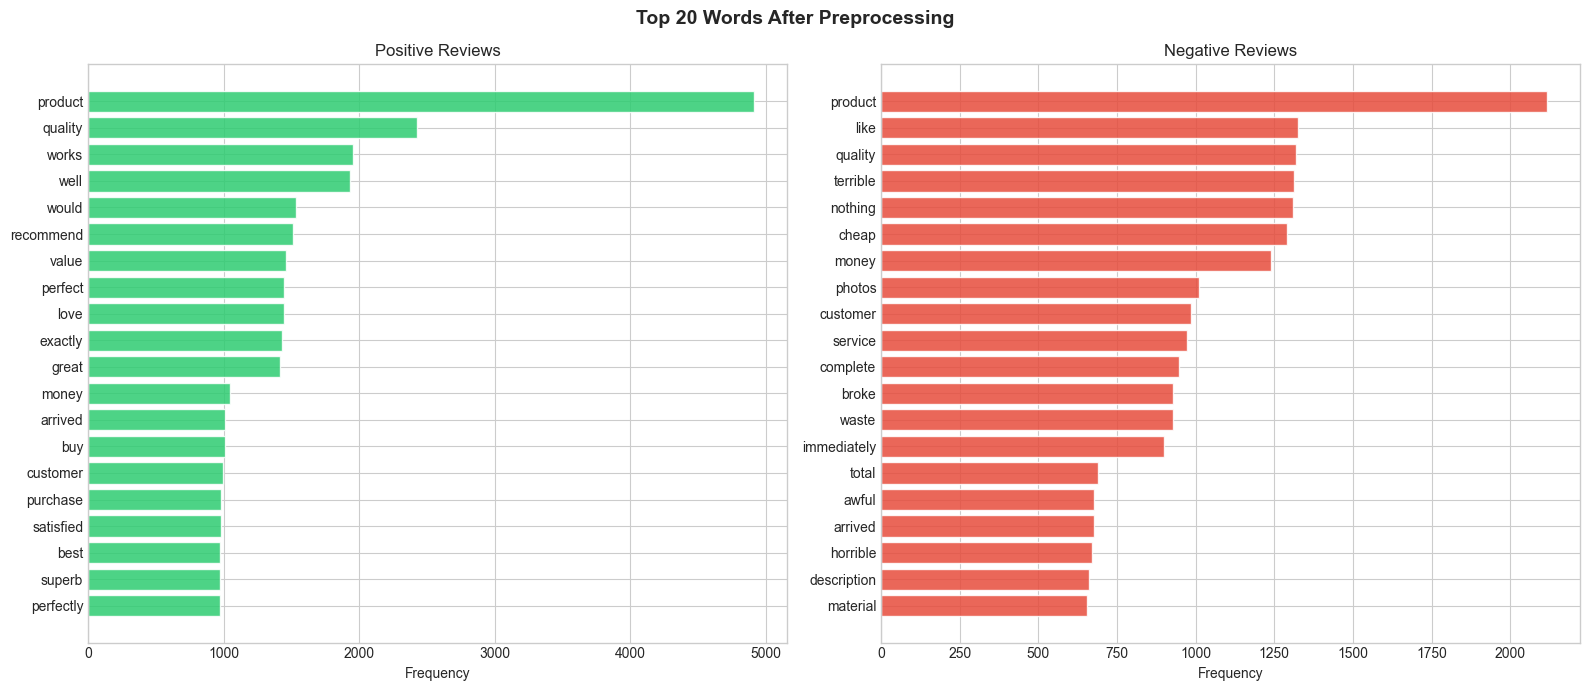

💾 Saved: nlp_02_top_words.png


In [5]:
# Visualise top words after cleaning
def top_words(texts, n=20):
    counts = Counter(' '.join(texts).split())
    return counts.most_common(n)

pos_words = top_words(df[df['sentiment']==1]['clean_text'])
neg_words = top_words(df[df['sentiment']==0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Words After Preprocessing', fontsize=14, fontweight='bold')

for ax, words, title, color in [
        (axes[0], pos_words, 'Positive Reviews', '#2ecc71'),
        (axes[1], neg_words, 'Negative Reviews', '#e74c3c')]:
    terms, counts = zip(*words)
    ax.barh(range(len(terms)), counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(terms))); ax.set_yticklabels(terms)
    ax.set_title(title); ax.set_xlabel('Frequency')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('nlp_02_top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_02_top_words.png')

---
## Step 4: Bag-of-Words vs TF-IDF — Text Vectorisation


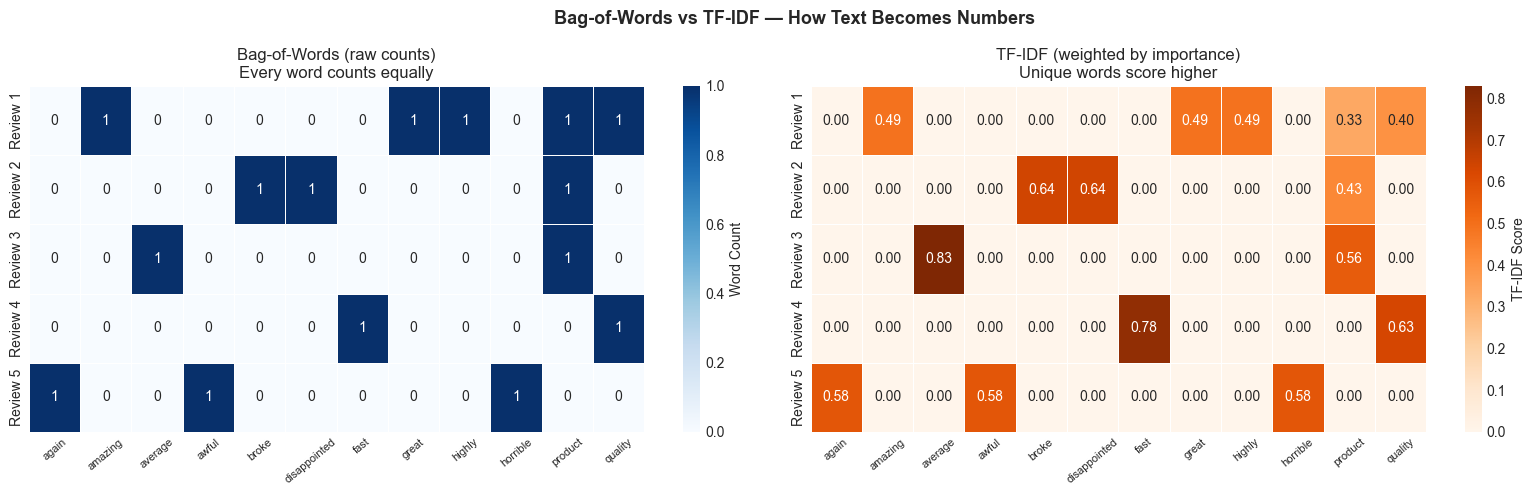

💾 Saved: nlp_03_tfidf_explained.png

💡 Key insight: "product" scores low in TF-IDF — it appears in ALL reviews.
   Words like "horrible" or "excellent" score high — they are distinctive signals.


In [ ]:

sample_reviews = [
    "great product amazing quality highly recommend",
    "terrible product broke waste money disappointed",
    "product okay average nothing special",
    "excellent fast shipping outstanding quality",
    "horrible experience awful service never again",
]

cv  = CountVectorizer(max_features=12) # CountVectorizer (BoW) 
tv  = TfidfVectorizer(max_features=12) # TfidfVectorizer 
# Convert text → numbers
bow_matrix   = cv.fit_transform(sample_reviews).toarray()
tfidf_matrix = tv.fit_transform(sample_reviews).toarray()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Bag-of-Words vs TF-IDF — How Text Becomes Numbers',
    fontsize=13, fontweight='bold')

sns.heatmap(bow_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=cv.get_feature_names_out(),
    yticklabels=[f'Review {i+1}' for i in range(5)],
    linewidths=0.5, linecolor='white', ax=axes[0],
    cbar_kws={'label': 'Word Count'})
axes[0].set_title('Bag-of-Words (raw counts)\nEvery word counts equally')
axes[0].tick_params(axis='x', rotation=40, labelsize=8)

sns.heatmap(tfidf_matrix.round(2), annot=True, fmt='.2f', cmap='Oranges',
    xticklabels=tv.get_feature_names_out(),
    yticklabels=[f'Review {i+1}' for i in range(5)],
    linewidths=0.5, linecolor='white', ax=axes[1],
    cbar_kws={'label': 'TF-IDF Score'})
axes[1].set_title('TF-IDF (weighted by importance)\nUnique words score higher')
axes[1].tick_params(axis='x', rotation=40, labelsize=8)

plt.tight_layout()
plt.savefig('nlp_03_tfidf_explained.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_03_tfidf_explained.png')
print()
print('💡 Key insight: "product" scores low in TF-IDF — it appears in ALL reviews.')
print('   Words like "horrible" or "excellent" score high — they are distinctive signals.')

---
## Step 5: Train / Test Split & Build Pipelines


In [ ]:
# இந்த code முழுக்க sentiment analysis ML training setup 

X = df['clean_text'] # 👉 X = input data (reviews text), X → “what user wrote”
y = df['sentiment'] # 👉 y = output label (sentiment) , y → “positive / negative”

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y 
)

# Train positive rate: 60%, Test positive rate : 60% => 👉 Perfect balance ✔, 👉 no bias ✔

print(f'✅ Train: {len(X_train):,} reviews  |  Test: {len(X_test):,} reviews')
print(f'   Train positive rate: {y_train.mean()*100:.1f}%')
print(f'   Test  positive rate: {y_test.mean()*100:.1f}%  (should match — stratified)')

# ── Build 4 model pipelines ────────────────────────────────────────────────
TFIDF = dict(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)
BOW   = dict(max_features=15000, ngram_range=(1, 2))

models = {
    'Naive Bayes (BoW)' : Pipeline([  # 👉 word count based model
        ('vec', CountVectorizer(**BOW)),
        ('clf', MultinomialNB(alpha=1.0)) 
    ]),
    'Naive Bayes (TF-IDF)' : Pipeline([ # 👉 importance-based input
        ('vec', TfidfVectorizer(**TFIDF)),
        ('clf', MultinomialNB(alpha=1.0))
    ]),
    'Logistic Regression' : Pipeline([ # 👉 positive / negative probability
        ('vec', TfidfVectorizer(**TFIDF)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
    ]),
    'Linear SVM' : Pipeline([ # 🧠 Very strong classifier for text
        ('vec', TfidfVectorizer(**TFIDF)),
        ('clf', LinearSVC(C=1.0, max_iter=2000, random_state=SEED))
    ]),
}

print(f'\n✅ Pipelines ready: {list(models.keys())}')
print('   Each pipeline: TF-IDF/BoW vectorisation → ML classifier')
print('   Vocabulary is fit ONLY on training data (no leakage!)')

✅ Train: 8,000 reviews  |  Test: 2,000 reviews
   Train positive rate: 60.0%
   Test  positive rate: 60.0%  (should match — stratified)

✅ Pipelines ready: ['Naive Bayes (BoW)', 'Naive Bayes (TF-IDF)', 'Logistic Regression', 'Linear SVM']
   Each pipeline: TF-IDF/BoW vectorisation → ML classifier
   Vocabulary is fit ONLY on training data (no leakage!)


---
## Step 6: Train & Evaluate All Models


In [ ]:

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print('━'*75)
print(f'  {"Model":<25} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"CV-Acc":>8}')
print('━'*75)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    cv   = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    cm   = confusion_matrix(y_test, pred)

    # ROC-AUC (only for models with predict_proba)
    try:
        proba = pipe.predict_proba(X_test)[:, 1]
        auc   = roc_auc_score(y_test, proba)
    except AttributeError:
        auc = None

    results[name] = dict(acc=acc, prec=prec, rec=rec, f1=f1,
                          cv=cv, cm=cm, pred=pred, auc=auc, pipe=pipe)
    flag = '⭐' if name == max(results, key=lambda k: results[k]['f1']) else '  '
    print(f'{flag} {name:<25} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {cv:>8.4f}')

print('━'*75)
best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\n🏆 Best model: {best_name}  (F1={results[best_name]["f1"]:.4f})')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model                         Acc    Prec     Rec      F1   CV-Acc
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⭐ Naive Bayes (BoW)          0.9915  0.9917  0.9942  0.9929   0.9907
   Naive Bayes (TF-IDF)       0.9900  0.9933  0.9900  0.9917   0.9904
⭐ Logistic Regression        0.9920  0.9909  0.9958  0.9933   0.9935
⭐ Linear SVM                 0.9945  0.9950  0.9958  0.9954   0.9955
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 Best model: Linear SVM  (F1=0.9954)


In [ ]:
print(f'📋 Classification Report — {best_name}:')
print(classification_report(y_test, results[best_name]['pred'],
      target_names=['Negative','Positive']))


📋 Classification Report — Linear SVM:
              precision    recall  f1-score   support

    Negative       0.99      0.99      0.99       800
    Positive       1.00      1.00      1.00      1200

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



---
## Step 7: Visualise Model Performance

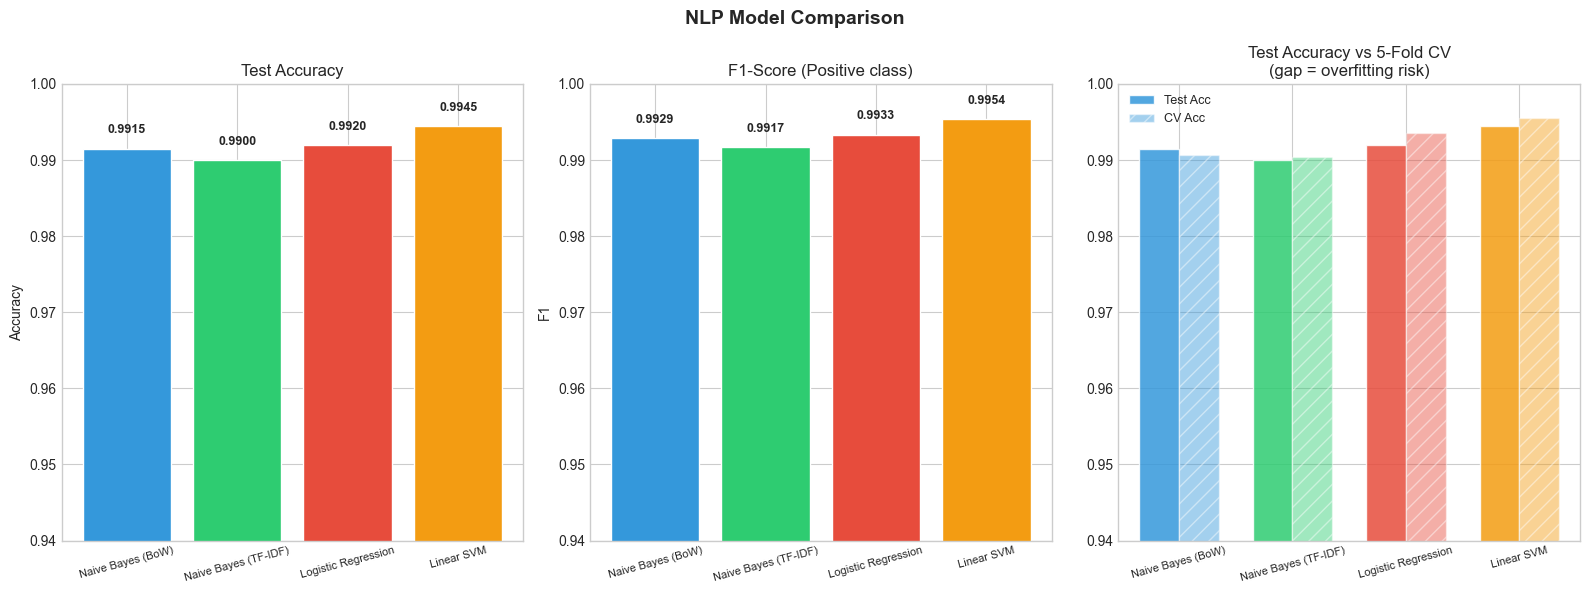

💾 Saved: nlp_04_model_comparison.png


In [ ]:
names  = list(results.keys())
accs   = [results[n]['acc']  for n in names]
f1s    = [results[n]['f1']   for n in names]
cvs    = [results[n]['cv']   for n in names]
precs  = [results[n]['prec'] for n in names]
recs   = [results[n]['rec']  for n in names]
cols   = ['#3498db','#2ecc71','#e74c3c','#f39c12']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('NLP Model Comparison', fontsize=14, fontweight='bold')

# Accuracy
axes[0].bar(names, accs, color=cols, edgecolor='white')
axes[0].set_title('Test Accuracy'); axes[0].set_ylabel('Accuracy')
y_lo = max(0.5, min(accs) - 0.05)
axes[0].set_ylim(y_lo, 1.0)
axes[0].tick_params(axis='x', rotation=15, labelsize=8)
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# F1-Score
axes[1].bar(names, f1s, color=cols, edgecolor='white')
axes[1].set_title('F1-Score (Positive class)'); axes[1].set_ylabel('F1')
axes[1].set_ylim(y_lo, 1.0)
axes[1].tick_params(axis='x', rotation=15, labelsize=8)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# Test vs CV
x = np.arange(len(names)); w = 0.35
axes[2].bar(x - w/2, accs, w, label='Test Acc', color=cols, edgecolor='white', alpha=0.85)
axes[2].bar(x + w/2, cvs,  w, label='CV Acc',   color=cols, edgecolor='white', alpha=0.45, hatch='//')
axes[2].set_title('Test Accuracy vs 5-Fold CV\n(gap = overfitting risk)')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=15, fontsize=8)
axes[2].set_ylim(y_lo, 1.0); axes[2].legend(fontsize=9)


plt.tight_layout()
plt.savefig('nlp_04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_04_model_comparison.png')

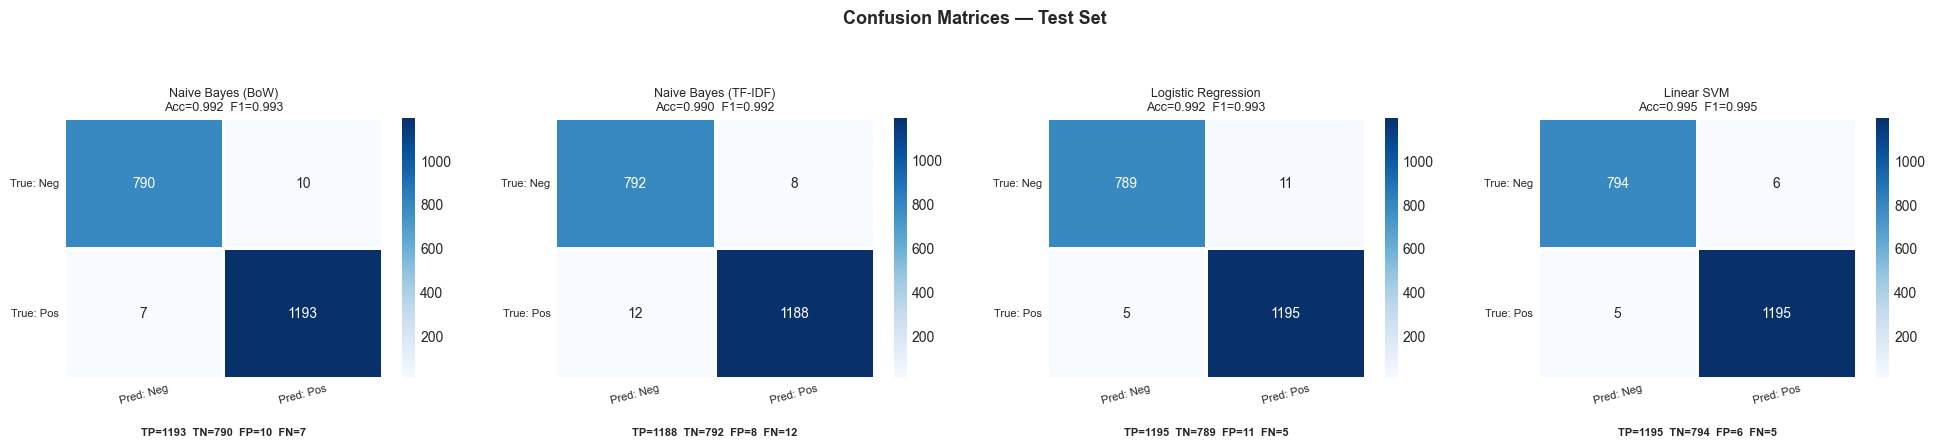

💾 Saved: nlp_05_confusion_matrices.png

📖 Confusion Matrix:
   TP = correctly predicted Positive
   TN = correctly predicted Negative
   FP = Negative predicted as Positive (false alarm)
   FN = Positive predicted as Negative (missed positive)


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')

for ax, name, c in zip(axes, names, cols):
    cm = results[name]['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        linewidths=1, linecolor='white',
        xticklabels=['Pred: Neg', 'Pred: Pos'],
        yticklabels=['True: Neg', 'True: Pos'])
    ax.set_title(f'{name}\nAcc={results[name]["acc"]:.3f}  F1={results[name]["f1"]:.3f}',
        fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    ax.tick_params(axis='y', labelsize=8, rotation=0)
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.22, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
        transform=ax.transAxes, ha='center', fontsize=8, fontweight='bold')

plt.tight_layout(pad=2.5)
plt.savefig('nlp_05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_05_confusion_matrices.png')
print()
print('📖 Confusion Matrix:')
print('   TP = correctly predicted Positive')
print('   TN = correctly predicted Negative')
print('   FP = Negative predicted as Positive (false alarm)')
print('   FN = Positive predicted as Negative (missed positive)')


---
## Step 8: Feature Importance — What Makes a Review Positive or Negative?


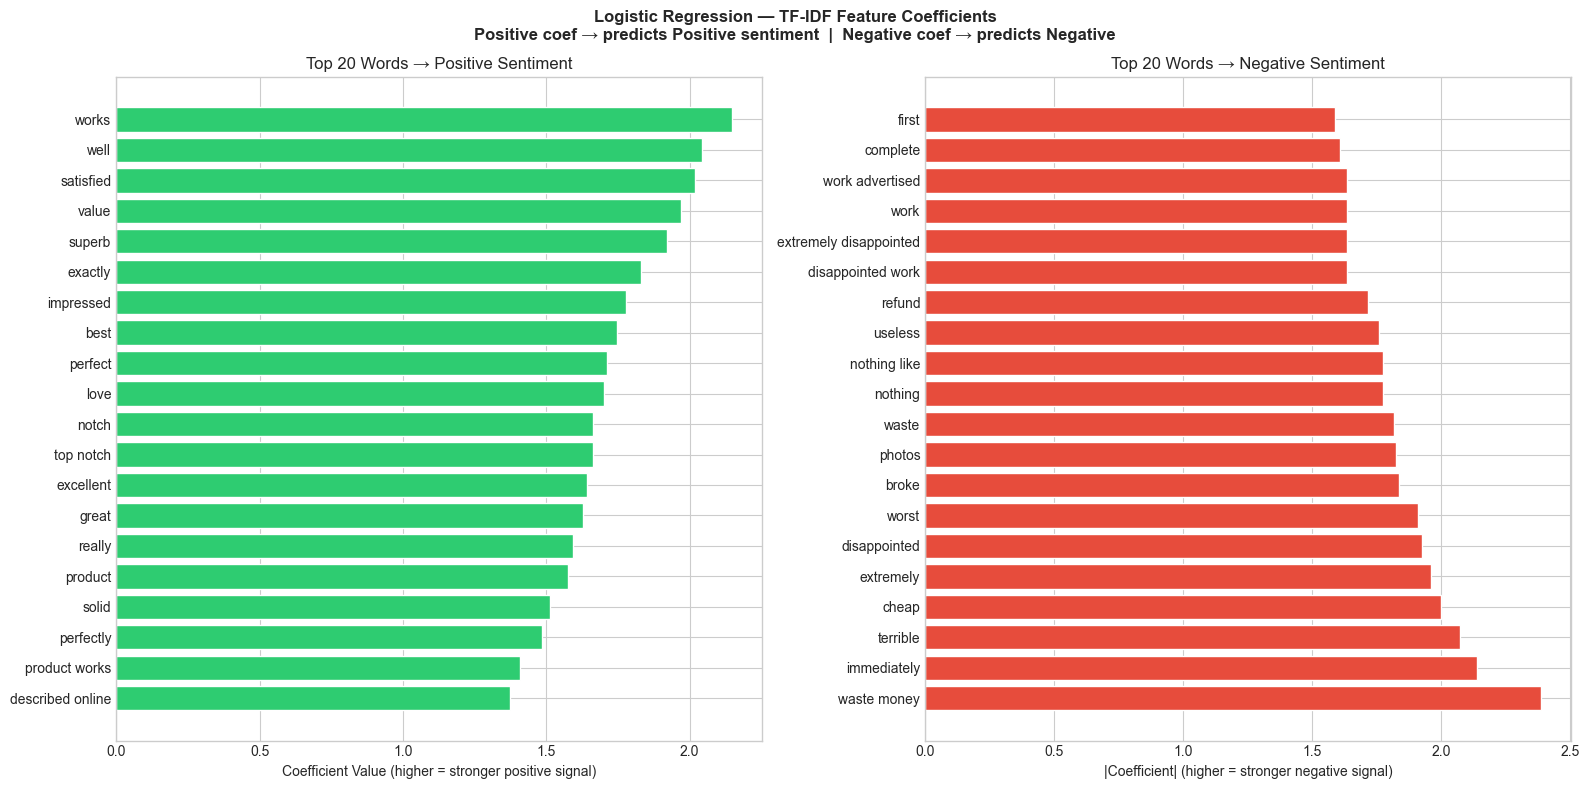

💾 Saved: nlp_06_feature_importance.png

🔬 Top 5 positive words: ['works', 'well', 'satisfied', 'value', 'superb']
🔬 Top 5 negative words: ['waste money', 'immediately', 'terrible', 'cheap', 'extremely']


In [ ]:
lr_pipe = results['Logistic Regression']['pipe'] 
vocab   = lr_pipe.named_steps['vec'].get_feature_names_out() 
coefs   = lr_pipe.named_steps['clf'].coef_[0] #  Get Coefficients
feat_series = pd.Series(coefs, index=vocab) # Create Pandas Series

top_pos = feat_series.nlargest(20) 
top_neg = feat_series.nsmallest(20) 

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Logistic Regression — TF-IDF Feature Coefficients\n'
    'Positive coef → predicts Positive sentiment  |  Negative coef → predicts Negative',
    fontsize=12, fontweight='bold')

axes[0].barh(top_pos.index[::-1], top_pos.values[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 20 Words → Positive Sentiment')
axes[0].set_xlabel('Coefficient Value (higher = stronger positive signal)')

axes[1].barh(top_neg.index, abs(top_neg.values), color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 20 Words → Negative Sentiment')
axes[1].set_xlabel('|Coefficient| (higher = stronger negative signal)')

plt.tight_layout()
plt.savefig('nlp_06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_06_feature_importance.png')
print()
print('🔬 Top 5 positive words:', top_pos.index[:5].tolist())
print('🔬 Top 5 negative words:', top_neg.index[:5].tolist())

---
## Step 9: N-gram Analysis — Bigrams Matter!

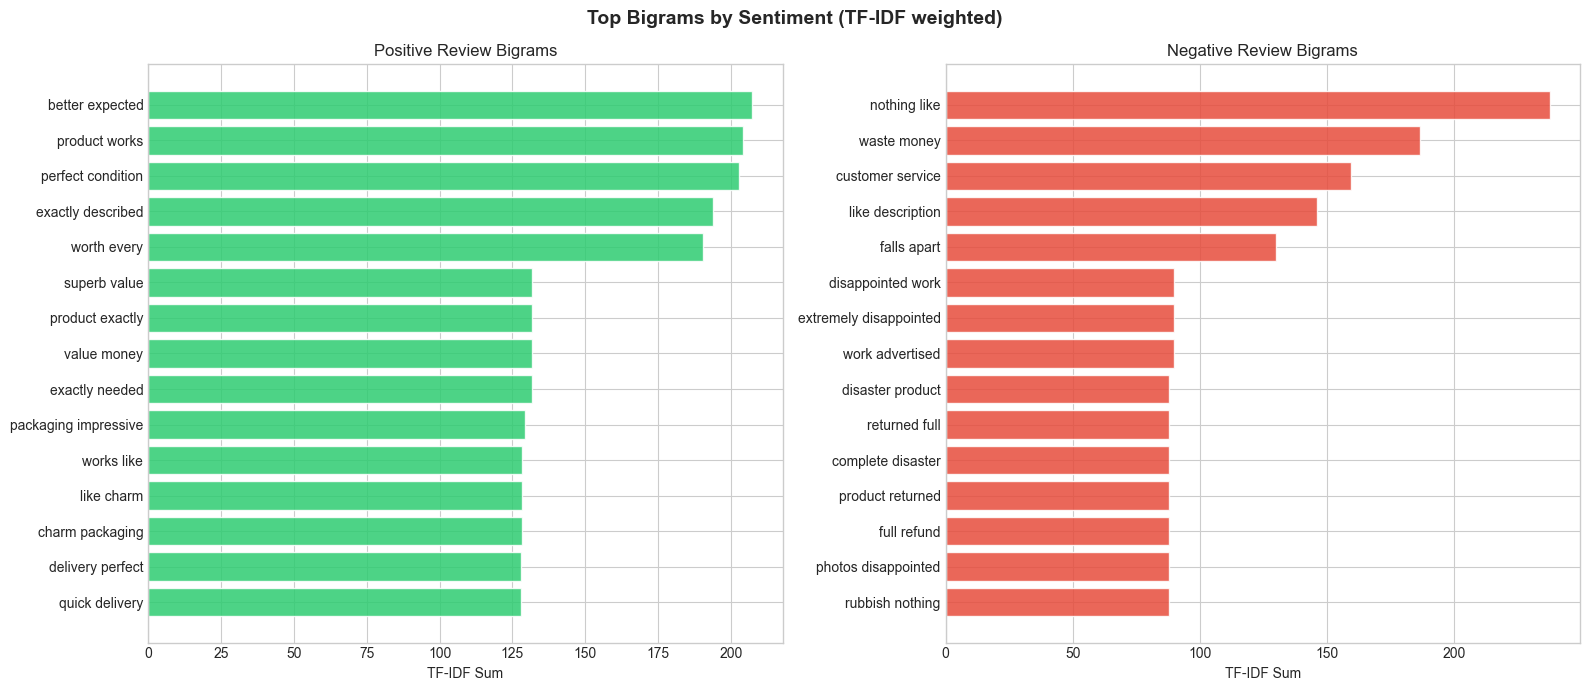

💾 Saved: nlp_07_bigrams.png


In [ ]:

tfidf_bigram = TfidfVectorizer(ngram_range=(2, 2), max_features=8000)
tfidf_bigram.fit(df['clean_text'])


def top_ngrams(texts, vectorizer, n=15): 
    mat  = vectorizer.transform(texts) 
    sums = np.asarray(mat.sum(axis=0)).flatten() 
    idx  = sums.argsort()[::-1][:n] 
    vocab = vectorizer.get_feature_names_out() 
    return [(vocab[i], sums[i]) for i in idx]  

pos_bigrams = top_ngrams(df[df['sentiment']==1]['clean_text'], tfidf_bigram)
neg_bigrams = top_ngrams(df[df['sentiment']==0]['clean_text'], tfidf_bigram)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top Bigrams by Sentiment (TF-IDF weighted)', fontsize=14, fontweight='bold')

for ax, ngrams, title, color in [
        (axes[0], pos_bigrams, 'Positive Review Bigrams', '#2ecc71'),
        (axes[1], neg_bigrams, 'Negative Review Bigrams', '#e74c3c')]:
    phrases, scores = zip(*ngrams)
    ax.barh(range(len(phrases)), scores, color=color, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(phrases))); ax.set_yticklabels(phrases)
    ax.set_title(title); ax.set_xlabel('TF-IDF Sum')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('nlp_07_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_07_bigrams.png')

---
## Step 10: Error Analysis

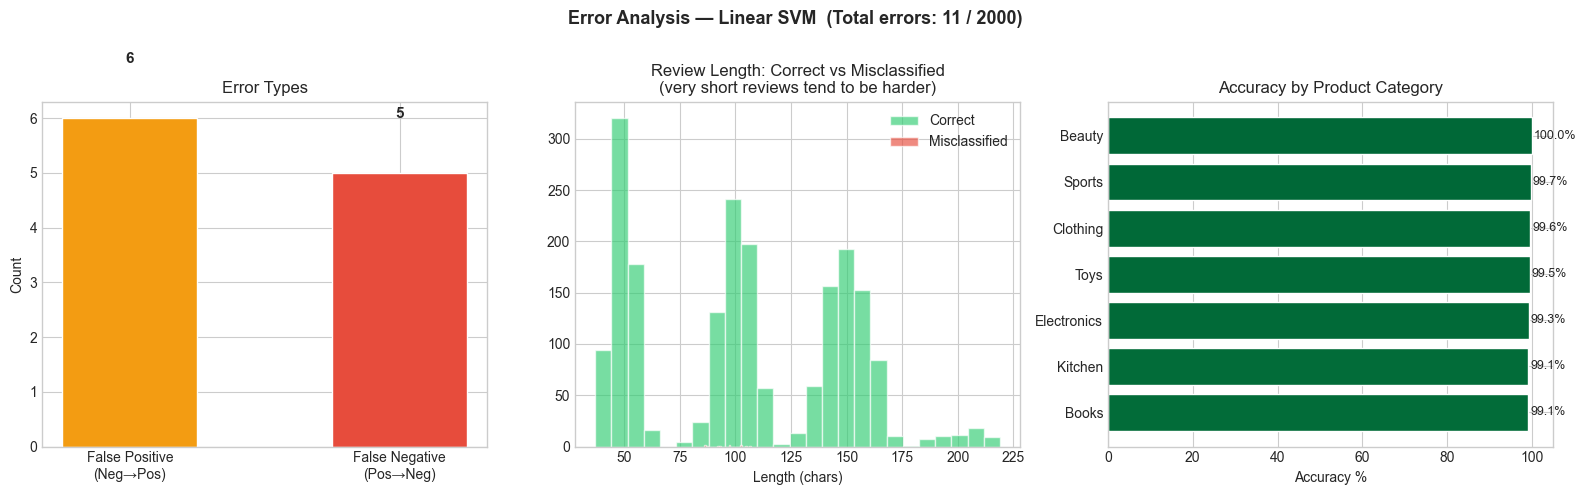

💾 Saved: nlp_08_error_analysis.png

Error breakdown:
  False Positives (Neg→Pos): 6  — predicted positive but was negative
  False Negatives (Pos→Neg): 5  — predicted negative but was positive

Misclassified examples:
  [Negative → Positive] appalling quality would recommend worst enemy love design comfortable worth every penny sp...
  [Positive → Negative] impressed durability still working perfectly months display cracked within week buttons fe...
  [Negative → Positive] horrible experience product useless support nonexistent works perfectly easy set complaint...


In [ ]:

# 1️⃣ Predictions & True Labels 
bp_pred   = results[best_name]['pred'] 
bp_labels = y_test.values # bp_labels → actual correct label
bp_texts  = np.array(X_test.tolist()) # bp_texts → review text data

wrong_mask = bp_pred != bp_labels

fp_count   = ((bp_pred == 1) & (bp_labels == 0)).sum()
fn_count   = ((bp_pred == 0) & (bp_labels == 1)).sum()

correct_lens = [len(t) for t, m in zip(bp_texts, ~wrong_mask) if m]
wrong_lens   = [len(t) for t, m in zip(bp_texts,  wrong_mask) if m]

cat_arr = df.loc[y_test.index, 'category'].values
cat_acc_df = pd.DataFrame({'cat': cat_arr, 'ok': bp_pred == bp_labels})
cat_acc    = cat_acc_df.groupby('cat')['ok'].mean().sort_values() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Error Analysis — {best_name}  '
    f'(Total errors: {wrong_mask.sum()} / {len(bp_labels)})',
    fontsize=13, fontweight='bold')

# Error types - False Positive vs False Negative count
axes[0].bar(['False Positive\n(Neg→Pos)', 'False Negative\n(Pos→Neg)'],
    [fp_count, fn_count], color=['#f39c12','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Error Types'); axes[0].set_ylabel('Count')
for i, v in enumerate([fp_count, fn_count]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=11)

# Length distribution - Review Length vs Error
axes[1].hist(correct_lens, bins=25, alpha=0.65, color='#2ecc71',
    edgecolor='white', label='Correct') # Correct reviews (green)
axes[1].hist(wrong_lens,   bins=25, alpha=0.65, color='#e74c3c',
    edgecolor='white', label='Misclassified') # Wrong reviews (red)
axes[1].set_title('Review Length: Correct vs Misclassified\n'
    '(very short reviews tend to be harder)')
axes[1].set_xlabel('Length (chars)'); axes[1].legend()

axes[2].barh(cat_acc.index, cat_acc.values,
    color=plt.cm.RdYlGn(cat_acc.values / 100), edgecolor='white')
axes[2].set_title('Accuracy by Product Category')
axes[2].set_xlabel('Accuracy %'); axes[2].set_xlim(0, 105)
for i, v in enumerate(cat_acc.values):
    axes[2].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nlp_08_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: nlp_08_error_analysis.png')
print()
print(f'Error breakdown:')
print(f'  False Positives (Neg→Pos): {fp_count}  — predicted positive but was negative')
print(f'  False Negatives (Pos→Neg): {fn_count}  — predicted negative but was positive')
print()
print('Misclassified examples:')
for text, true, pred in zip(bp_texts[wrong_mask][:3], bp_labels[wrong_mask][:3], bp_pred[wrong_mask][:3]):
    true_lbl = 'Positive' if true == 1 else 'Negative'
    pred_lbl = 'Positive' if pred == 1 else 'Negative'
    print(f'  [{true_lbl} → {pred_lbl}] {text[:90]}...')


---
## Step 11: Hyperparameter Tuning with GridSearchCV

In [ ]:
print('🔍 GridSearchCV — Logistic Regression (this takes ~1-2 min)...')

lr_tune_pipe = Pipeline([
    ('vec', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid = {
    'vec__max_features':  [8000, 15000], 
    'vec__ngram_range':   [(1, 1), (1, 2)], 
    'clf__C':             [0.1, 1.0, 5.0, 10.0],
}

gs = GridSearchCV(lr_tune_pipe, param_grid, cv=skf, scoring='f1',
    n_jobs=-1, verbose=0, refit=True)
gs.fit(X_train, y_train)

best_pred_gs = gs.predict(X_test)
print(f'\n✅ GridSearchCV complete')
print(f'   Best CV F1    : {gs.best_score_:.4f}') # 👉 training validation performance
print(f'   Test Accuracy : {accuracy_score(y_test, best_pred_gs):.4f}') # 👉 real-world performance
print(f'   Test F1       : {f1_score(y_test, best_pred_gs):.4f}') # 👉 precision + recall balance
print(f'\n   Best params:')
for k, v in gs.best_params_.items():
    print(f'     {k:<30}: {v}')


🔍 GridSearchCV — Logistic Regression (this takes ~1-2 min)...

✅ GridSearchCV complete
   Best CV F1    : 0.9959
   Test Accuracy : 0.9935
   Test F1       : 0.9946

   Best params:
     clf__C                        : 10.0
     vec__max_features             : 8000
     vec__ngram_range              : (1, 2)



## Step 12: Predict Sentiment for Any Review

In [18]:
# Use the best pipeline
best_pipeline = results[best_name]['pipe']

def predict_sentiment(review_text, pipeline=None, threshold=0.5):
    """
    Predict sentiment for a new review.

    Parameters
    ----------
    review_text : str  — raw review text (no preprocessing needed)
    pipeline    : fitted sklearn Pipeline (defaults to best model)
    threshold   : probability threshold (only used for models with predict_proba)

    Returns
    -------
    dict with sentiment label, confidence, and cleaned text
    """
    if pipeline is None:
        pipeline = best_pipeline

    clean  = preprocess_text(review_text)
    pred   = pipeline.predict([clean])[0]
    label  = 'Positive ✅' if pred == 1 else 'Negative ❌'

    try:
        proba      = pipeline.predict_proba([clean])[0]
        confidence = max(proba) * 100
        conf_label = 'High' if confidence > 80 else 'Medium' if confidence > 60 else 'Low'
    except AttributeError:
        confidence = None
        conf_label = 'N/A (SVM does not output probabilities)'

    print('━' * 55)
    print('  💬 SENTIMENT PREDICTION')
    print('━' * 55)
    print(f'  Raw text   : {review_text[:70]}...' if len(review_text)>70 else f'  Raw text   : {review_text}')
    print(f'  Cleaned    : {clean[:70]}...' if len(clean)>70 else f'  Cleaned    : {clean}')
    print(f'  Sentiment  : {label}')
    if confidence:
        print(f'  Confidence : {confidence:.1f}%  ({conf_label})')
    print('━' * 55)
    return {'sentiment': pred, 'label': label, 'confidence': confidence, 'clean': clean}


# ── Test cases ─────────────────────────────────────────────────────────────
test_reviews = [
    "Absolutely love this product! Works perfectly and arrived super fast. Highly recommend!",
    "Complete waste of money. Broke after two days. Terrible quality. Do NOT buy.",
    "It's okay I guess. Nothing special but does the job. Average product overall.",
    "The packaging was damaged BUT the product inside is actually really good. Mixed feelings.",
    "WORST PURCHASE EVER!!! Total scam. Looks nothing like the photos. Returning immediately!!!",
]

print(f'Using best model: {best_name}\n')
for review in test_reviews:
    predict_sentiment(review)
    print()

Using best model: Linear SVM

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💬 SENTIMENT PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw text   : Absolutely love this product! Works perfectly and arrived super fast. ...
  Cleaned    : absolutely love product works perfectly arrived super fast highly reco...
  Sentiment  : Positive ✅
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💬 SENTIMENT PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw text   : Complete waste of money. Broke after two days. Terrible quality. Do NO...
  Cleaned    : complete waste money broke two days terrible quality buy
  Sentiment  : Negative ❌
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  💬 SENTIMENT PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw text   : It's okay I guess. Nothing special but 

---
## Step 13: Deploy as a Flask API

Wrap the model in a REST API so any app can send a review and get sentiment back.

**Usage:**
```bash
# Start the server
python sentiment_api.py

# Test with curl
curl -X POST http://localhost:5000/predict \
     -H 'Content-Type: application/json' \
     -d '{"review": "Amazing product, works perfectly!"}'
```

In [ ]:
import pickle, os

# Save the best model to disk
model_path = 'sentiment_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_pipeline, f) # Python object-ஐ file save 

print(f'✅ Model saved: {model_path}')
print(f'   File size: {os.path.getsize(model_path)/1024:.1f} KB')

# Write the Flask API file
FLASK_CODE = '''#!/usr/bin/env python3
"""
Amazon Review Sentiment API
Stage 7 — NLP Project  |  ML Roadmap

Usage:
    pip install flask scikit-learn pandas numpy
    python sentiment_api.py

Endpoints:
    POST /predict  — JSON body: {"review": "your review text"}
    GET  /health   — health check
"""
import re, pickle
from flask import Flask, request, jsonify

app = Flask(__name__)

# ── Load model ──────────────────────────────────────────────────────────────
with open('sentiment_model.pkl', 'rb') as f:
    model = pickle.load(f)

STOP = set("""i me my myself we our ours ourselves you your yours yourself
    yourselves he him his himself she her hers herself it its itself they them
    their theirs themselves what which who whom this that these those am is are
    was were be been being have has had having do does did doing a an the and
    but if or because as until while of at by for with about between into
    through during before after above below to from up down in out on off over
    under again then once here there when where why how all both each few more
    most other some no not only same so than too very can will just should now
    also get got however""".split())

def clean(text):
    t = re.sub(r"[^a-zA-Z\\s]", " ", str(text).lower())
    t = re.sub(r"\\s+", " ", t).strip()
    return " ".join(w for w in t.split() if w not in STOP and len(w) > 2)


@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    if not data or "review" not in data:
        return jsonify({"error": "Missing 'review' field in request body"}), 400

    raw   = data["review"]
    c     = clean(raw)
    pred  = int(model.predict([c])[0])
    label = "Positive" if pred == 1 else "Negative"

    try:
        proba = model.predict_proba([c])[0]
        conf  = float(round(max(proba) * 100, 2))
    except AttributeError:
        conf = None

    return jsonify({
        "sentiment":   label,
        "label_code":  pred,
        "confidence":  conf,
        "clean_text":  c,
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "SentimentClassifier"})


if __name__ == "__main__":
    print("🚀 Sentiment API running on http://localhost:5000")
    print("   POST /predict  — {'review': 'your text'}  →  {'sentiment': 'Positive'}")
    app.run(debug=True, port=5000)
'''

with open('sentiment_api.py', 'w') as f:
    f.write(FLASK_CODE)

print('✅ Flask API saved: sentiment_api.py')
print()
print('To run the API:')
print('  pip install flask')
print('  python sentiment_api.py')
print()
print('To test:')
print('  curl -X POST http://localhost:5000/predict \\')
print('       -H \'Content-Type: application/json\' \\')
print('       -d \'{"review": "Amazing product!"}\' ')

✅ Model saved: sentiment_model.pkl
   File size: 103.1 KB
✅ Flask API saved: sentiment_api.py

To run the API:
  pip install flask
  python sentiment_api.py

To test:
  curl -X POST http://localhost:5000/predict \
       -H 'Content-Type: application/json' \
       -d '{"review": "Amazing product!"}' 




**GitHub README:**
- Show `nlp_06_feature_importance.png` — proves model interpretability
- Show `nlp_07_bigrams.png` — demonstrates bigram understanding
- Include model comparison table with all metrics
